### Import Statements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

In [2]:
data = pd.read_csv("Data/netflix_titles.csv", encoding="latin-1")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(f"The data contains {data.shape[0]} rows and {data.shape[1]} columns")

The data contains 8809 rows and 12 columns


### Data cleaning

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8809 non-null   object
 1   type          8809 non-null   object
 2   title         8809 non-null   object
 3   director      6175 non-null   object
 4   cast          7984 non-null   object
 5   country       7978 non-null   object
 6   date_added    8799 non-null   object
 7   release_year  8809 non-null   int64 
 8   rating        8805 non-null   object
 9   duration      8806 non-null   object
 10  listed_in     8809 non-null   object
 11  description   8809 non-null   object
dtypes: int64(1), object(11)
memory usage: 826.0+ KB


#### Checking for duplicates

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data = data.drop_duplicates()

#### Checking for & handling missing values

In [7]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Feature engineering

In [8]:
# Fill categorical columns with 'Unknown'
cols_to_fill = ['director', 'cast', 'country', 'rating', 'listed_in']

for col in cols_to_fill:
    data[col] = data[col].fillna('Unknown')

# Convert date_added to datetime
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
data["year_added"] = data["date_added"].dt.year
data["month_added"] = data["date_added"].dt.month

In [10]:
data["type"].value_counts()

type
Movie      6132
TV Show    2677
Name: count, dtype: int64

#### Cleaning the duration column

In [11]:
# Extract numeric duration
data["duration_int"] = data["duration"].str.extract(r"(\d+)").astype(float)
data["duration_type"] = data["duration"].str.extract(r"([a-zA-Z]+)")

#### Splitting multi-value columns

In [12]:
data["country"] = data["country"].str.split(", ")
data["listed_in"] = data["listed_in"].str.split(", ")

In [13]:
country_exploded = data.explode("country")

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8809 non-null   object        
 1   type           8809 non-null   object        
 2   title          8809 non-null   object        
 3   director       8809 non-null   object        
 4   cast           8809 non-null   object        
 5   country        8809 non-null   object        
 6   date_added     8711 non-null   datetime64[ns]
 7   release_year   8809 non-null   int64         
 8   rating         8809 non-null   object        
 9   duration       8806 non-null   object        
 10  listed_in      8809 non-null   object        
 11  description    8809 non-null   object        
 12  year_added     8711 non-null   float64       
 13  month_added    8711 non-null   float64       
 14  duration_int   8806 non-null   float64       
 15  duration_type  8806 n

In [15]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_int,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0,9.0,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,[Unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2021.0,9.0,2.0,Seasons


In [16]:
data.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_int,duration_type
count,8809,8809,8809,8809,8809,8809,8711,8809.000000,8809,8806,8809,8809,8711.000000,8711.000000,8806.000000,8806
unique,8809,2,8806,4530,7695,749,NaN,NaN,19,220,516,8777,NaN,NaN,NaN,3
top,s1,Movie,15-Aug,Unknown,Unknown,[United States],NaN,NaN,TV-MA,1 Season,"[Dramas, International Movies]","Paranormal activity at a lush, abandoned prope...",NaN,NaN,NaN,min
freq,1,6132,2,2634,825,2819,NaN,NaN,3208,1794,362,4,NaN,NaN,NaN,6129
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-23 11:33:38.000229632,2014.181292,NaN,NaN,NaN,NaN,2018.889106,6.652738,69.843629,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,2008.000000,1.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-20 00:00:00,2013.000000,NaN,NaN,NaN,NaN,2018.000000,4.000000,2.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-12 00:00:00,2017.000000,NaN,NaN,NaN,NaN,2019.000000,7.000000,88.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-26 00:00:00,2019.000000,NaN,NaN,NaN,NaN,2020.000000,10.000000,106.000000,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-05 00:00:00,2024.000000,NaN,NaN,NaN,NaN,2024.000000,12.000000,312.000000,NaN


#### How has Netflix content grown over time?

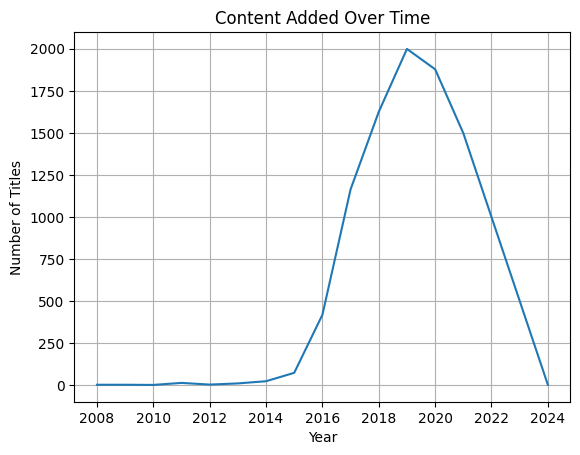

In [39]:
content_growth = data.groupby("year_added").size()
content_growth.plot()

plt.title("Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid()
plt.show()

##### Netflix has significantly expanded its content library over the years, with a sharp increase after 2015

#### Movies vs TV shows distribution

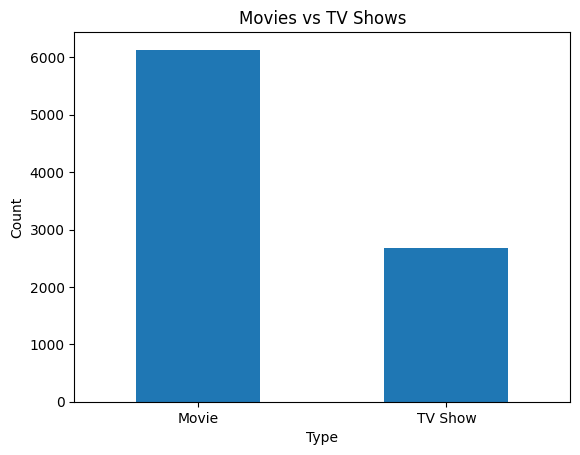

In [31]:
data["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

##### Netflix's content library is heavily skewed towards movies, with approximately twice as many movies as TV shows, indicating a stronger emphasis on film content

#### Top producing countries

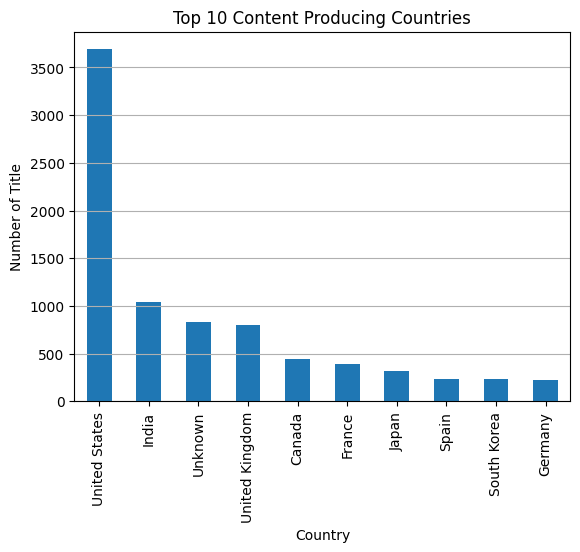

In [32]:
top_countries = country_exploded["country"].value_counts().head(10)
top_countries.plot(kind="bar")

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Title")
plt.grid(axis="y")
plt.show()

##### The United States is the leading producer of content on Netflix, contributing more titles than any other country

#### Most popular genres

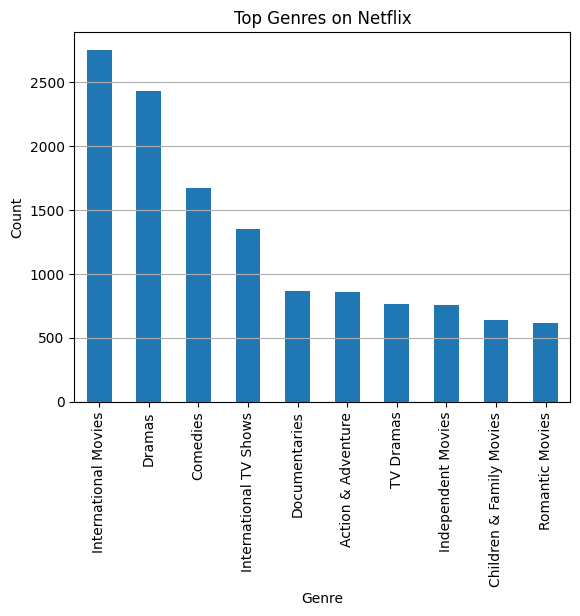

In [38]:
genre_exploded = data.explode("listed_in")
top_genres = genre_exploded["listed_in"].value_counts().head(10)
top_genres.plot(kind="bar")

plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

##### Netflix offers a diverse range of genres, with International Movies and Dramas among the most frequently occuring categories

#### Content added by month

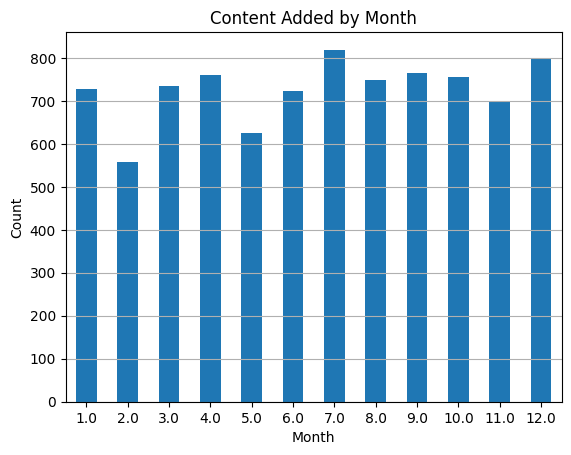

In [37]:
monthly_content = data["month_added"].value_counts().sort_index()
monthly_content.plot(kind="bar")

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##### Netflix adds content consistently throughout the year, with no extreme spikes, indicating a steady content release strategy

#### Movie duration analysis

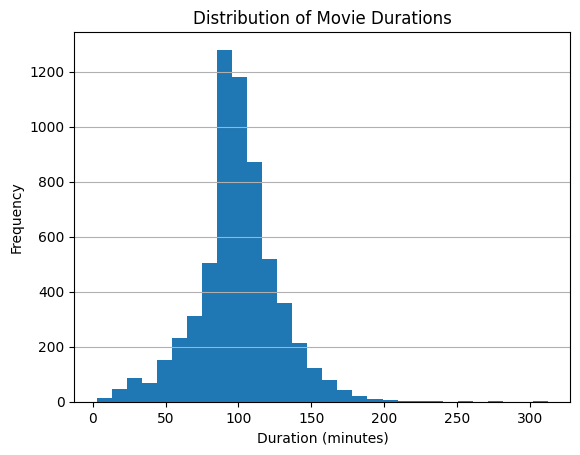

In [36]:
movies = data[data["duration_type"] == "min"]
movies["duration_int"].plot(kind="hist", bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.grid(axis="y")
plt.show()

##### Most movies on Netflix have durations between 90 and 120 minutes, suggesting a standard feature-length format.

#### TV shows: Number of seasons

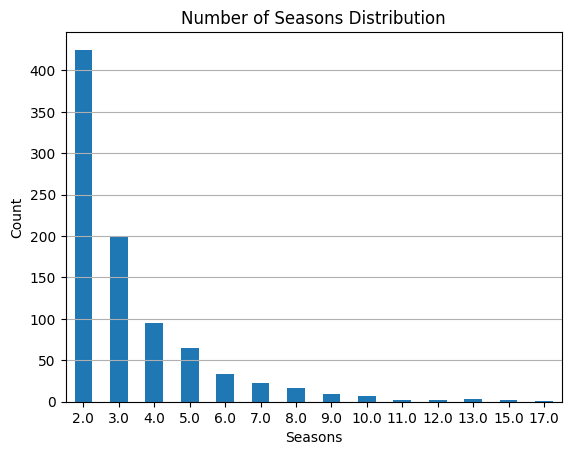

In [35]:
tv_shows = data[data["duration_type"] == "Seasons"]
tv_shows["duration_int"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##### Most TV shows on Netflix have between 1 and 2 seasons, indicating a tendency toward shorter series

#### Ratings distribution

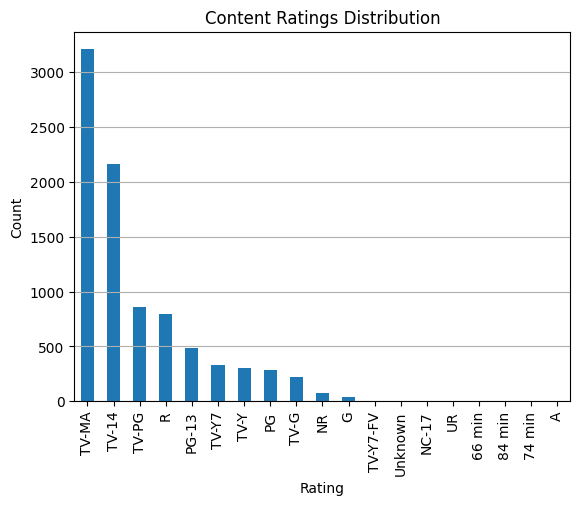

In [34]:
data["rating"].value_counts().plot(kind="bar")
plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

#### Most content on Neflix falls under TV-MA and TV-14 classifications, indicating a strong focus on mature and teen audiences. This suggests that netflix primarily targets older viewers with content that includes more comolex themes and storytelling

#### Growth of Movies Vs TV Shows over time

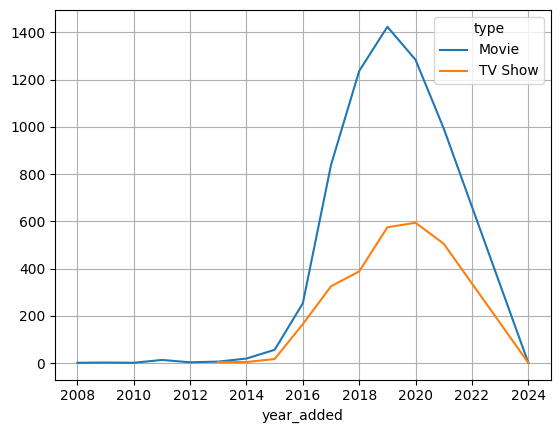

In [40]:
data.groupby(["year_added", "type"]).size().unstack().plot()
plt.grid()

### Key Insights and Conclusions
- Netflix content has grown significantly after 2015, reflecting global expansion
- The platform heavily favors movies over TV shows
- The United States Dominates content production
- Content spans diverse genres, with strong representation of international and drama categories
- Most movies follow a standard 90 - 120 minute duration
- TV shows tend to be short, withh 1-2 seasons
- Content is added consistently throughout the year, indicating a steady release strategy

### Business Implications
- Netflix prioritizes quantity and consistency in content delivery
- Shorter TV series may reflect experimentation or cost control
- Strong international genre presence suggests a global audience strategy

##### 